# 📊 PlantVillage Dataset Analysis

## Phase 1 — Advanced Dataset Analysis

### Objectives

This notebook performs a detailed analysis of the PlantVillage dataset before any preprocessing or model training.

The main objectives are:

- Analyze class imbalance
- Compute dataset statistics
- Calculate RGB mean and standard deviation
- Generate normalization values
- Validate dataset integrity
- Produce a professional EDA report
- Prepare the dataset for preprocessing

---

### Dataset Information

- Dataset: PlantVillage
- Classes: 38
- Images: 43,444
- Image Size: 256 × 256
- Task: Multi-class Image Classification

---

Expected Output

By the end of this notebook we will have:

✅ Class imbalance report

✅ RGB statistics

✅ Normalization values

✅ Dataset validation report

✅ Professional EDA summary

These outputs will be used directly in the preprocessing and training pipeline.

In [2]:
# ==========================================================
# Import Libraries
# ==========================================================

import random
import hashlib
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [5]:
# ==========================================================
# Configuration
# ==========================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

DATASET_DIR = Path("/content/drive/MyDrive/PlantVillage/train")

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

print("Dataset:", DATASET_DIR)

print("Seed:", SEED)

Dataset: /content/drive/MyDrive/PlantVillage/train
Seed: 42


In [6]:
# ==========================================================
# Load Dataset Summary
# ==========================================================

class_names = sorted(
    [
        folder.name
        for folder in DATASET_DIR.iterdir()
        if folder.is_dir()
    ]
)

summary = []

for cls in class_names:

    count = len(
        [
            x
            for x in (DATASET_DIR / cls).iterdir()
            if x.suffix.lower() in IMAGE_EXTENSIONS
        ]
    )

    summary.append(
        {
            "Class": cls,
            "Images": count
        }
    )

summary_df = pd.DataFrame(summary)

summary_df = summary_df.sort_values(
    by="Images",
    ascending=False
).reset_index(drop=True)

display(summary_df.head())

print()

print("Total Images :", summary_df["Images"].sum())

print("Total Classes:", len(summary_df))

,Class,Images
0,Orange___Haunglongbing_(Citrus_greening),4405
1,Tomato___Tomato_Yellow_Leaf_Curl_Virus,4286
2,Soybean___healthy,4072
3,Peach___Bacterial_spot,1838
4,Tomato___Bacterial_spot,1702



Total Images : 43444
Total Classes: 38


In [7]:
# ==========================================================
# Class Imbalance Analysis
# ==========================================================

average = summary_df["Images"].mean()

median = summary_df["Images"].median()

threshold = average * 0.60

summary_df["Category"] = np.where(
    summary_df["Images"] < threshold,
    "Minority",
    "Majority"
)

minority = summary_df[
    summary_df["Category"] == "Minority"
]

majority = summary_df[
    summary_df["Category"] == "Majority"
]

print("=" * 60)

print("CLASS IMBALANCE REPORT")

print("=" * 60)

print(f"Average Images : {average:.2f}")

print(f"Median Images  : {median:.2f}")

print(f"Threshold      : {threshold:.2f}")

print()

print(f"Majority Classes : {len(majority)}")

print(f"Minority Classes : {len(minority)}")

display(minority)

CLASS IMBALANCE REPORT
Average Images : 1143.26
Median Images  : 874.00
Threshold      : 685.96

Majority Classes : 27
Minority Classes : 11


,Class,Images,Category
27,Cherry_(including_sour)___healthy,684,Minority
28,Apple___Apple_scab,504,Minority
29,Apple___Black_rot,496,Minority
30,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,410,Minority
31,Strawberry___healthy,364,Minority
32,Grape___healthy,339,Minority
33,Tomato___Tomato_mosaic_virus,299,Minority
34,Raspberry___healthy,297,Minority
35,Peach___healthy,288,Minority
36,Apple___Cedar_apple_rust,220,Minority


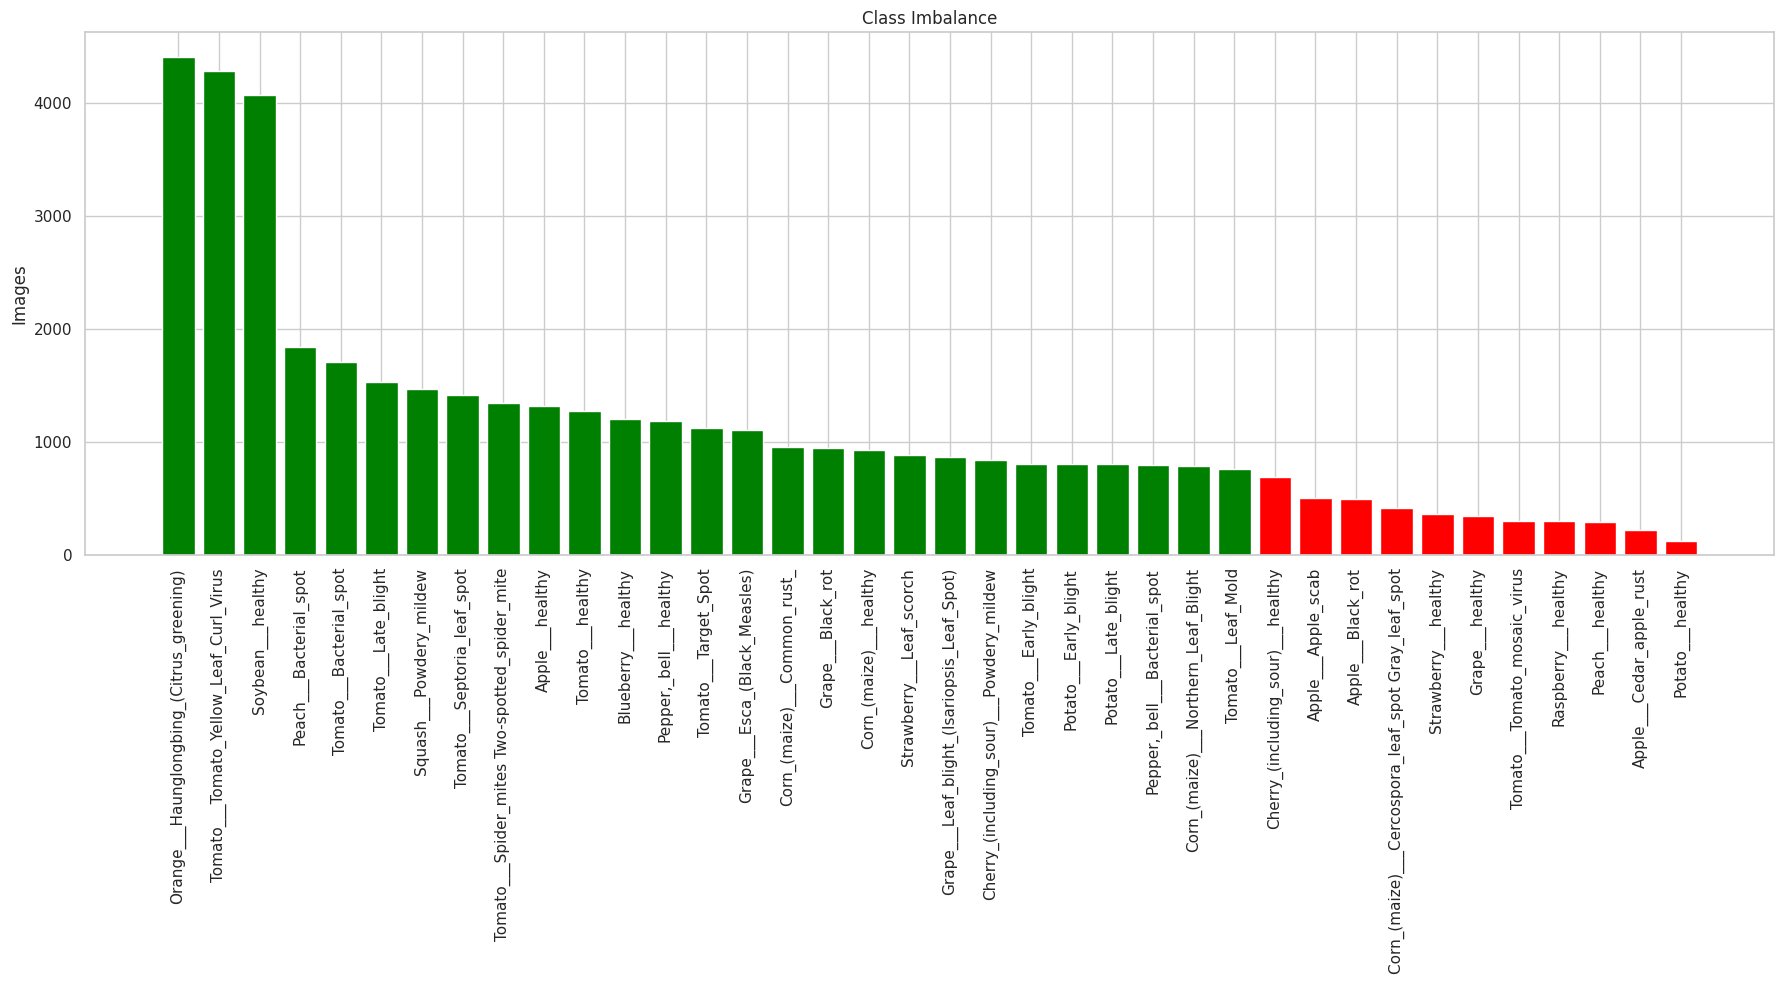

In [8]:
# ==========================================================
# Visualize Majority vs Minority
# ==========================================================

plt.figure(figsize=(18,10))

colors = summary_df["Category"].map(
    {
        "Majority":"green",
        "Minority":"red"
    }
)

plt.bar(
    summary_df["Class"],
    summary_df["Images"],
    color=colors
)

plt.xticks(rotation=90)

plt.ylabel("Images")

plt.title("Class Imbalance")

plt.tight_layout()

plt.show()

# 🌈 RGB Channel Statistics

Deep learning models perform better when input images are normalized.

To compute normalization values, we first calculate the mean and standard deviation of the RGB channels across a representative sample of the dataset.

These statistics will later be used during preprocessing and model training.

In [9]:
# ==========================================================
# Compute RGB Mean and Standard Deviation
# ==========================================================

NUM_IMAGES = 1000

all_images = []

for cls in class_names:

    class_path = DATASET_DIR / cls

    all_images.extend(
        list(class_path.glob("*"))
    )

random.shuffle(all_images)

sample_images = all_images[:NUM_IMAGES]

channel_sum = np.zeros(3, dtype=np.float64)

channel_squared_sum = np.zeros(3, dtype=np.float64)

total_pixels = 0

for image_path in tqdm(sample_images):

    img = cv2.imread(str(image_path))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img.astype(np.float32) / 255.0

    pixels = img.reshape(-1, 3)

    channel_sum += pixels.sum(axis=0)

    channel_squared_sum += (pixels ** 2).sum(axis=0)

    total_pixels += pixels.shape[0]

mean = channel_sum / total_pixels

std = np.sqrt(
    (channel_squared_sum / total_pixels) - (mean ** 2)
)

print("=" * 60)
print("RGB STATISTICS")
print("=" * 60)

print("Mean :", mean)

print("Std  :", std)

  0%|          | 0/1000 [00:00<?, ?it/s]

RGB STATISTICS
Mean : [0.47070307 0.49220807 0.41435447]
Std  : [0.20245461 0.17620312 0.22066444]


,Channel,Mean,Std
0,Red,0.470703,0.202455
1,Green,0.492208,0.176203
2,Blue,0.414354,0.220664


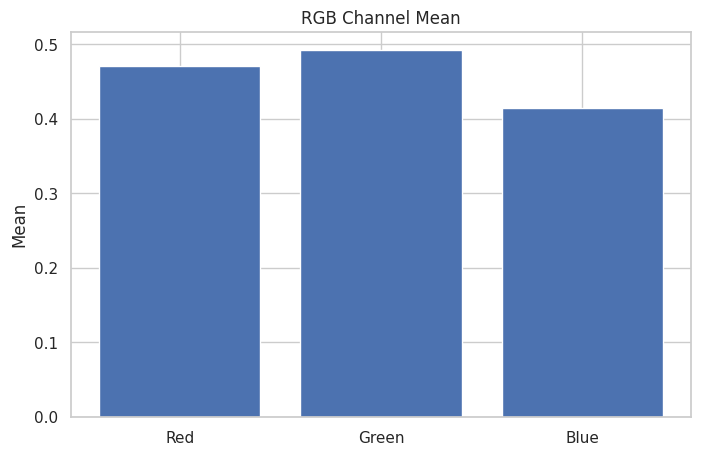

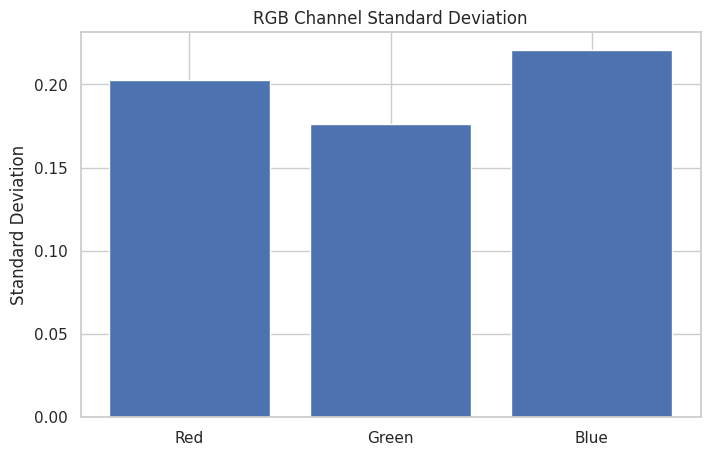

In [10]:
# ==========================================================
# Visualize Mean and Standard Deviation
# ==========================================================

rgb_df = pd.DataFrame(
    {
        "Channel": ["Red", "Green", "Blue"],
        "Mean": mean,
        "Std": std,
    }
)

display(rgb_df)

plt.figure(figsize=(8, 5))

plt.bar(rgb_df["Channel"], rgb_df["Mean"])

plt.title("RGB Channel Mean")

plt.ylabel("Mean")

plt.show()

plt.figure(figsize=(8, 5))

plt.bar(rgb_df["Channel"], rgb_df["Std"])

plt.title("RGB Channel Standard Deviation")

plt.ylabel("Standard Deviation")

plt.show()

# 📌 Normalization Reference

The computed RGB mean and standard deviation values will be used later during preprocessing.

There are two common normalization strategies:

1. **Simple Rescaling (0–1)** using `Rescaling(1./255)` in TensorFlow. This is sufficient for most CNNs trained from scratch.

2. **Model-Specific Preprocessing** using functions such as:
   - `tf.keras.applications.efficientnet.preprocess_input`
   - `tf.keras.applications.resnet.preprocess_input`

For this project:

- **Custom CNN** → Use `Rescaling(1./255)`
- **EfficientNetB0** → Use the official EfficientNet preprocessing
- **ResNet50** → Use the official ResNet preprocessing

This ensures each architecture receives inputs in the format it was designed for.

In [11]:
# ==========================================================
# Dataset Integrity Validation
# ==========================================================

missing_files = 0
invalid_images = 0

for cls in tqdm(class_names):

    class_path = DATASET_DIR / cls

    for image_path in class_path.glob("*"):

        if not image_path.exists():

            missing_files += 1

            continue

        try:

            img = Image.open(image_path)

            img.verify()

        except Exception:

            invalid_images += 1

print("=" * 60)
print("DATASET VALIDATION")
print("=" * 60)

print(f"Missing Files : {missing_files}")
print(f"Invalid Images: {invalid_images}")

  0%|          | 0/38 [00:00<?, ?it/s]

DATASET VALIDATION
Missing Files : 0
Invalid Images: 0


In [13]:
quality_report = pd.DataFrame({
    "Metric": [
        "Total Classes",
        "Total Images",
        "Corrupted Images",
        "Missing Files",
        "Image Format",
        "Dataset Status"
    ],
    "Value": [
        len(class_names),
        summary_df["Images"].sum(),
        invalid_images,
        missing_files,
        "JPEG/PNG",
        "Ready for Preprocessing"
    ]
})

display(quality_report)

,Metric,Value
0,Total Classes,38
1,Total Images,43444
2,Corrupted Images,0
3,Missing Files,0
4,Image Format,JPEG/PNG
5,Dataset Status,Ready for Preprocessing


# 🌿 Plant Species Distribution

Until now, our analysis has focused on disease classes.

In this section, we aggregate the dataset at the plant-species level to understand how many images belong to each crop.

This helps identify whether the dataset is dominated by a small number of plant species, which could introduce bias during training.

,Plant,Images
0,Tomato,14529
1,Orange,4405
2,Soybean,4072
3,Grape,3251
4,Corn_(maize),3080
5,Apple,2536
6,Peach,2126
7,"Pepper,_bell",1980
8,Potato,1721
9,Cherry_(including_sour),1526


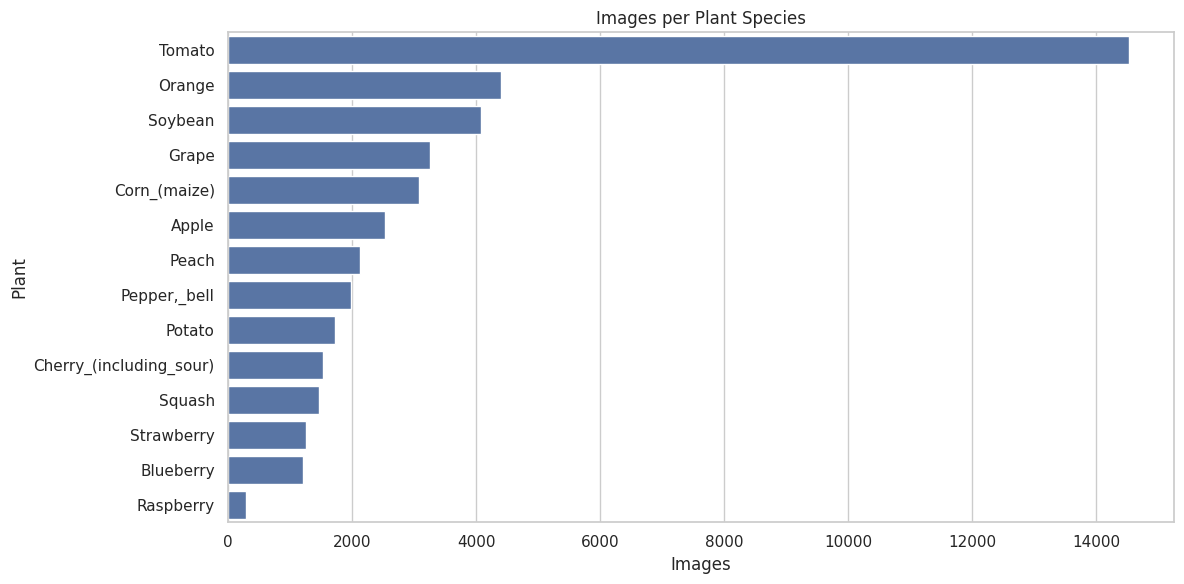

In [14]:
# ==========================================================
# Plant Species Distribution
# ==========================================================

species_counts = {}

for class_name, count in zip(summary_df["Class"], summary_df["Images"]):

    species = class_name.split("___")[0]

    species_counts[species] = species_counts.get(species, 0) + count

species_df = (
    pd.DataFrame(
        species_counts.items(),
        columns=["Plant", "Images"]
    )
    .sort_values("Images", ascending=False)
    .reset_index(drop=True)
)

display(species_df)

plt.figure(figsize=(12,6))

sns.barplot(
    data=species_df,
    x="Images",
    y="Plant"
)

plt.title("Images per Plant Species")

plt.tight_layout()

plt.show()